# Predicting 30-Day Hospital Readmission

This notebook develops and evaluates machine-learning models for predicting readmission within 30 days.

To prevent patient-level data leakage, all encounters belonging to one patient are assigned to either the training set or the test set—never both. Preprocessing and model fitting are performed using training data only.

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [49]:
project_root = Path.cwd()

if not (project_root / "data").exists():
    project_root = project_root.parent

clean_data_path = (
    project_root
    / "data"
    / "processed"
    / "hospital_readmissions_clean.csv"
)

tables_path = project_root / "reports" / "tables"
figures_path = project_root / "reports" / "figures"

tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

encounters = pd.read_csv(clean_data_path, low_memory=False)

print("Encounters:", f"{len(encounters):,}")
print("Unique patients:", f"{encounters['patient_nbr'].nunique():,}")
print(
    "Readmission rate:",
    f"{encounters['readmitted_30d'].mean() * 100:.2f}%"
)

Encounters: 99,340
Unique patients: 69,987
Readmission rate: 11.39%


## Feature exclusions

The following variables are excluded from the predictor matrix:

- `encounter_id`: Arbitrary encounter identifier
- `patient_nbr`: Patient identifier used only for group splitting
- `readmitted`: Original version of the outcome
- `readmitted_30d`: Binary model target
- `diag_1`, `diag_2`, and `diag_3`: Sparse raw ICD-9 codes replaced by broader diagnosis groups
- Numeric admission, discharge, and admission-source IDs: Replaced by readable categorical descriptions

All retained predictors describe information available by the time of discharge. No feature directly contains the subsequent readmission outcome.

In [50]:
excluded_features = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d",
    "diag_1",
    "diag_2",
    "diag_3",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

feature_columns = [
    column
    for column in encounters.columns
    if column not in excluded_features
]

X = encounters[feature_columns].copy()
y = encounters["readmitted_30d"].copy()
groups = encounters["patient_nbr"].copy()

print("Predictor columns:", X.shape[1])
print("Target observations:", len(y))

Predictor columns: 44
Target observations: 99340


In [51]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

groups_train = groups.iloc[train_index].copy()
groups_test = groups.iloc[test_index].copy()

In [52]:
shared_patients = set(groups_train).intersection(set(groups_test))

assert len(shared_patients) == 0
assert len(X_train) + len(X_test) == len(X)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

split_summary = pd.DataFrame({
    "split": ["Training", "Testing"],
    "encounters": [len(X_train), len(X_test)],
    "unique_patients": [
        groups_train.nunique(),
        groups_test.nunique()
    ],
    "readmissions": [
        int(y_train.sum()),
        int(y_test.sum())
    ],
    "readmission_rate_pct": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

split_summary.to_csv(
    tables_path / "patient_level_split_summary.csv",
    index=False
)

print("Shared patients:", len(shared_patients))
split_summary

Shared patients: 0


,split,encounters,unique_patients,readmissions,readmission_rate_pct
0,Training,79567,55989,9070,11.40
1,Testing,19773,13998,2244,11.35


In [53]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_features = [
    column
    for column in feature_columns
    if column not in numeric_features
]

numeric_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 8
Categorical features: 36


## Split validation

The patient-level split produced no overlap between training and testing patients. The 30-day readmission rate was 11.40% in training data and 11.35% in testing data, indicating that the outcome distribution remained well balanced across the two patient groups.

All preprocessing will be embedded inside model pipelines fitted only on the training set. The test set will remain untouched until final model evaluation.

In [54]:
from time import perf_counter

import joblib

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [55]:
dummy_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        DummyClassifier(
            strategy="prior"
        )
    )
])

logistic_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            random_state=42
        )
    )
])

random_forest_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42
        )
    )
])

models = {
    "Dummy classifier": dummy_pipeline,
    "Logistic regression": logistic_pipeline,
    "Random forest": random_forest_pipeline
}

In [56]:
training_times = {}
trained_models = {}

for model_name, model_pipeline in models.items():
    print(f"Training {model_name}...")

    start_time = perf_counter()

    model_pipeline.fit(X_train, y_train)

    elapsed_time = perf_counter() - start_time

    training_times[model_name] = elapsed_time
    trained_models[model_name] = model_pipeline

    print(
        f"Completed {model_name} in "
        f"{elapsed_time:.2f} seconds.\n"
    )

Training Dummy classifier...
Completed Dummy classifier in 0.71 seconds.

Training Logistic regression...
Completed Logistic regression in 4.54 seconds.

Training Random forest...
Completed Random forest in 13.02 seconds.



In [57]:
training_summary = pd.DataFrame({
    "model": list(training_times.keys()),
    "training_time_seconds": [
        round(value, 2)
        for value in training_times.values()
    ]
})

training_summary.to_csv(
    tables_path / "model_training_times.csv",
    index=False
)

training_summary

,model,training_time_seconds
0,Dummy classifier,0.71
1,Logistic regression,4.54
2,Random forest,13.02


In [58]:
models_path = project_root / "models"
models_path.mkdir(parents=True, exist_ok=True)

model_filenames = {
    "Dummy classifier": "dummy_classifier.joblib",
    "Logistic regression": "logistic_regression.joblib",
    "Random forest": "random_forest.joblib"
}

for model_name, filename in model_filenames.items():
    output_path = models_path / filename

    joblib.dump(
        trained_models[model_name],
        output_path
    )

    print(f"Saved {model_name}: {output_path}")

Saved Dummy classifier: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\dummy_classifier.joblib
Saved Logistic regression: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\logistic_regression.joblib
Saved Random forest: c:\Users\ezont\Desktop\PersonalProj\hospital_readmission_prediction\models\random_forest.joblib


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay

VILLANOVA_NAVY = "#00205B"
LIGHT_BLUE = "#5BC2E7"
GRAY = "#6B7280"

sns.set_theme(style="whitegrid")

In [60]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [61]:
models_path = project_root / "models"

evaluated_models = {
    "Dummy classifier": joblib.load(
        models_path / "dummy_classifier.joblib"
    ),
    "Logistic regression": joblib.load(
        models_path / "logistic_regression.joblib"
    ),
    "Random forest": joblib.load(
        models_path / "random_forest.joblib"
    )
}

print("Loaded models:", list(evaluated_models.keys()))

Loaded models: ['Dummy classifier', 'Logistic regression', 'Random forest']


In [62]:
def calculate_metrics(
    model_name,
    y_true,
    predicted_probability,
    threshold=0.50
):
    predicted_class = (
        predicted_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted_class
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(
            y_true,
            predicted_probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            predicted_probability
        ),
        "precision": precision_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "brier_score": brier_score_loss(
            y_true,
            predicted_probability
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

In [63]:
predicted_probabilities = {}
evaluation_records = []

for model_name, model in evaluated_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]

    predicted_probabilities[model_name] = probabilities

    evaluation_records.append(
        calculate_metrics(
            model_name,
            y_test,
            probabilities,
            threshold=0.50
        )
    )

evaluation_results = pd.DataFrame(evaluation_records)

metric_columns = [
    "model",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "specificity",
    "f1",
    "brier_score"
]

evaluation_results[metric_columns].round(3)

,model,roc_auc,pr_auc,precision,recall,specificity,f1,brier_score
0,Dummy classifier,0.500,0.113,0.000,0.000,1.000,0.000,0.101
1,Logistic regression,0.669,0.225,0.547,0.018,0.998,0.035,0.096
2,Random forest,0.675,0.222,0.192,0.550,0.703,0.284,0.215


In [64]:
evaluation_results.to_csv(
    tables_path / "model_evaluation_default_threshold.csv",
    index=False
)

evaluation_results.round(4)

,model,threshold,roc_auc,pr_auc,precision,recall,specificity,f1,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,Dummy classifier,0.5,0.5000,0.1135,0.0000,0.0000,1.0000,0.0000,0.1006,17529,0,2244,0
1,Logistic regression,0.5,0.6689,0.2249,0.5467,0.0183,0.9981,0.0354,0.0960,17495,34,2203,41
2,Random forest,0.5,0.6751,0.2217,0.1917,0.5499,0.7032,0.2843,0.2149,12326,5203,1010,1234


In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

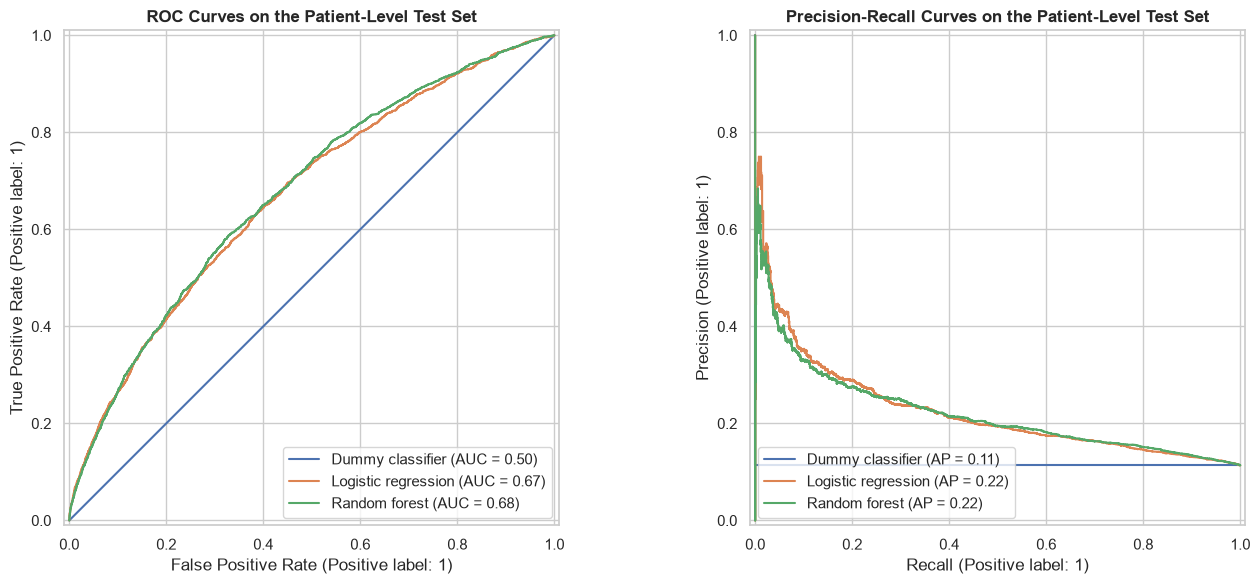

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model_name, probabilities in predicted_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axes[0]
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axes[1]
    )

axes[0].set_title(
    "ROC Curves on the Patient-Level Test Set",
    fontweight="bold"
)
axes[1].set_title(
    "Precision-Recall Curves on the Patient-Level Test Set",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    figures_path / "roc_and_precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
thresholds = [0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
threshold_records = []

for model_name in [
    "Logistic regression",
    "Random forest"
]:
    probabilities = predicted_probabilities[model_name]

    for threshold in thresholds:
        threshold_records.append(
            calculate_metrics(
                model_name,
                y_test,
                probabilities,
                threshold=threshold
            )
        )

threshold_results = pd.DataFrame(threshold_records)

threshold_results.to_csv(
    tables_path / "model_threshold_comparison.csv",
    index=False
)

threshold_results[
    [
        "model",
        "threshold",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
].round(3)

,model,threshold,precision,recall,specificity,f1
0,Logistic regression,0.10,0.167,0.660,0.579,0.267
1,Logistic regression,0.15,0.232,0.346,0.854,0.278
2,Logistic regression,0.20,0.287,0.205,0.935,0.239
3,Logistic regression,0.30,0.389,0.078,0.984,0.131
4,Logistic regression,0.40,0.469,0.037,0.995,0.068
5,Logistic regression,0.50,0.547,0.018,0.998,0.035
6,Random forest,0.10,0.113,1.000,0.000,0.204
7,Random forest,0.15,0.113,1.000,0.000,0.204
8,Random forest,0.20,0.113,1.000,0.000,0.204
9,Random forest,0.30,0.116,0.995,0.025,0.207


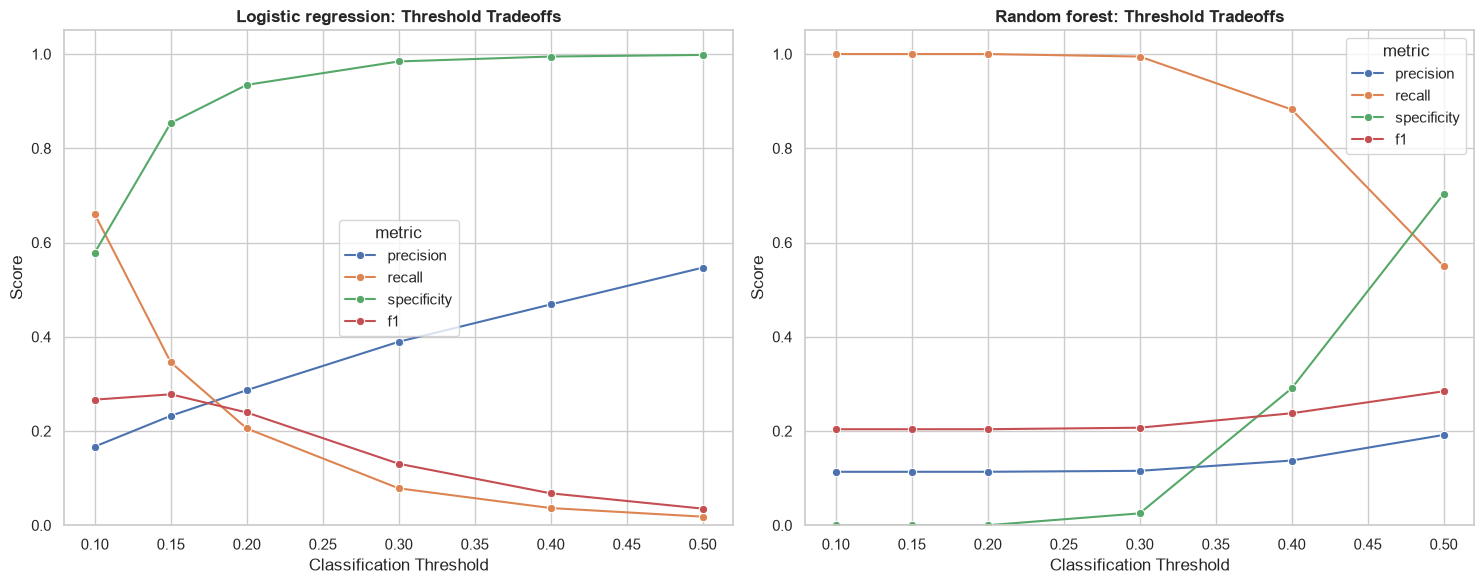

In [68]:
threshold_plot_data = threshold_results.melt(
    id_vars=["model", "threshold"],
    value_vars=["precision", "recall", "specificity", "f1"],
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, model_name in zip(
    axes,
    ["Logistic regression", "Random forest"]
):
    model_data = threshold_plot_data[
        threshold_plot_data["model"] == model_name
    ]

    sns.lineplot(
        data=model_data,
        x="threshold",
        y="score",
        hue="metric",
        marker="o",
        ax=ax
    )

    ax.set_title(
        f"{model_name}: Threshold Tradeoffs",
        fontweight="bold"
    )
    ax.set_xlabel("Classification Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)

plt.tight_layout()

plt.savefig(
    figures_path / "threshold_tradeoffs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model-evaluation findings

At the default 0.50 classification threshold:

- The dummy classifier had no ability to distinguish encounters resulting in readmission from those that did not.
- Logistic regression achieved a ROC-AUC of 0.669 and the highest PR-AUC of 0.225. Its Brier score of 0.096 indicated better probability accuracy than the random forest. However, the default threshold identified only 41 of 2,244 readmissions, producing 1.8% recall.
- The random forest achieved the highest ROC-AUC at 0.675. It identified 1,234 of 2,244 readmissions, producing 55.0% recall, but also incorrectly flagged 5,203 encounters. Its precision was 19.2%.
- Both trained models substantially exceeded the dummy classifier's PR-AUC of 0.113, although overall discrimination remained moderate.

The threshold analysis demonstrates that classification performance depends on the relative consequences of false negatives and false positives:

- At a 0.10 threshold, logistic-regression recall increased to 66.0%, while precision decreased to 16.7%.
- Logistic regression achieved its highest displayed F1 score of 0.278 at a 0.15 threshold.
- The random forest achieved its highest displayed F1 score of 0.284 at its default 0.50 threshold.
- Random-forest thresholds below 0.30 classified nearly every encounter as positive because class weighting shifted its predicted probabilities upward.

These thresholds are presented as a sensitivity analysis rather than optimized clinical cutoffs. Selecting an operating threshold for actual use would require external validation, explicit consideration of intervention capacity, and clinical input regarding the relative costs of missed readmissions and unnecessary follow-up.

Neither model is suitable for clinical deployment. The results demonstrate a historical, educational machine-learning workflow rather than a validated clinical decision system.

In [69]:
from sklearn.inspection import permutation_importance

In [70]:
logistic_model = evaluated_models["Logistic regression"]

logistic_preprocessor = logistic_model.named_steps["preprocessor"]
logistic_estimator = logistic_model.named_steps["model"]

transformed_feature_names = (
    logistic_preprocessor.get_feature_names_out()
)

coefficient_results = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient": logistic_estimator.coef_[0]
})

coefficient_results["odds_ratio"] = np.exp(
    coefficient_results["coefficient"]
)

coefficient_results["feature"] = (
    coefficient_results["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_results["absolute_coefficient"] = (
    coefficient_results["coefficient"].abs()
)

coefficient_results.to_csv(
    tables_path / "logistic_regression_coefficients.csv",
    index=False
)

top_positive_coefficients = (
    coefficient_results
    .nlargest(15, "coefficient")
)

top_negative_coefficients = (
    coefficient_results
    .nsmallest(15, "coefficient")
)

display(top_positive_coefficients)
display(top_negative_coefficients)

,feature,coefficient,odds_ratio,absolute_coefficient
164,discharge_disposition_Still patient or expecte...,1.277966,3.589332,1.277966
156,discharge_disposition_Discharged/transferred w...,1.182312,3.261908,1.182312
158,discharge_disposition_Discharged/transferred/r...,1.104506,3.017732,1.104506
144,discharge_disposition_Admitted as an inpatient...,0.842903,2.323102,0.842903
151,discharge_disposition_Discharged/transferred t...,0.737147,2.089963,0.737147
173,admission_source_Not Mapped,0.473510,1.605620,0.473510
76,acarbose_Up,0.442447,1.556512,0.442447
153,discharge_disposition_Discharged/transferred t...,0.362147,1.436410,0.362147
41,repaglinide_Up,0.330012,1.390984,0.330012
6,number_inpatient,0.324088,1.382769,0.324088


,feature,coefficient,odds_ratio,absolute_coefficient
16,age_[0-10),-1.238742,0.289749,1.238742
149,discharge_disposition_Discharged/transferred t...,-0.993718,0.370198,0.993718
159,discharge_disposition_Discharged/transferred/r...,-0.781477,0.457729,0.781477
142,admission_type_Trauma Center,-0.687256,0.502954,0.687256
163,discharge_disposition_Not Mapped,-0.682285,0.505461,0.682285
157,discharge_disposition_Discharged/transferred/r...,-0.635411,0.529718,0.635411
38,repaglinide_Down,-0.612921,0.541766,0.612921
162,discharge_disposition_Neonate discharged to an...,-0.611021,0.542796,0.611021
145,discharge_disposition_Discharged to home,-0.560811,0.570746,0.560811
75,acarbose_Steady,-0.528122,0.589711,0.528122


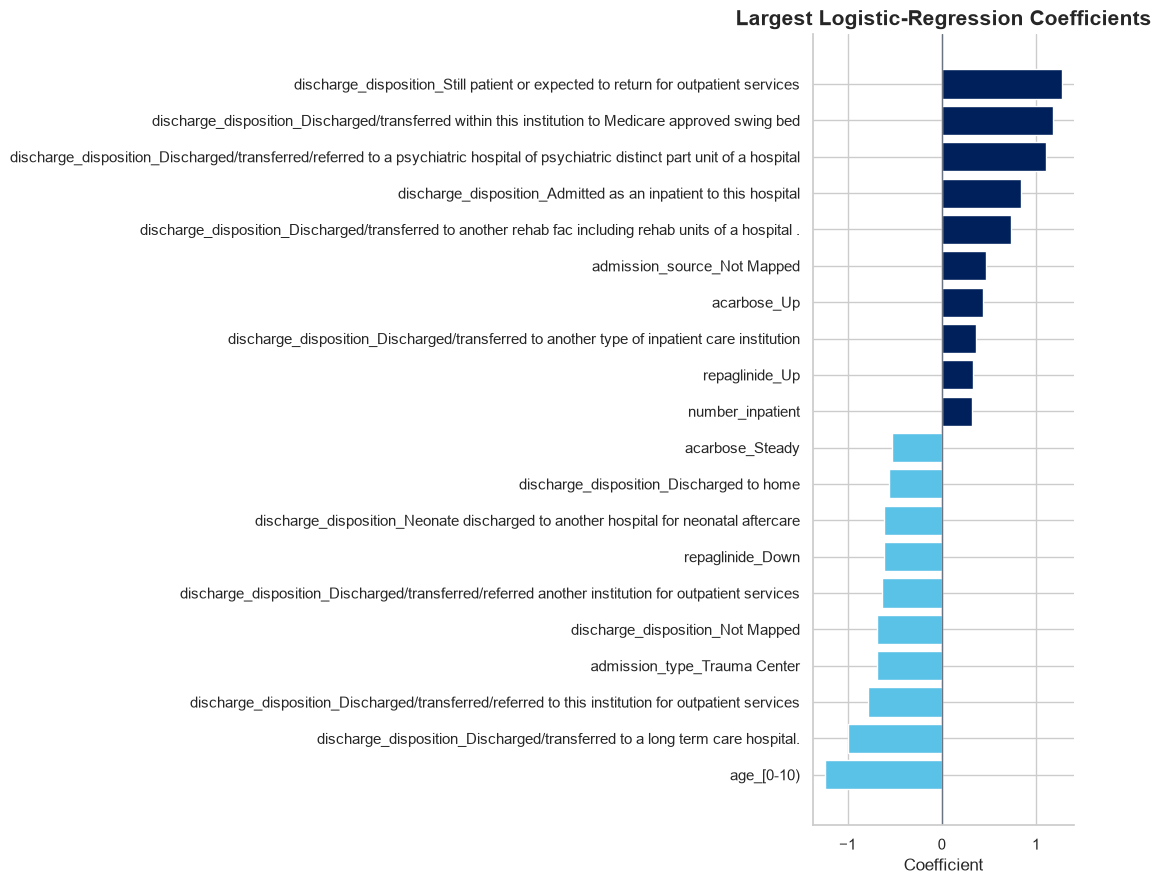

In [71]:
coefficient_plot_data = pd.concat([
    top_positive_coefficients.head(10),
    top_negative_coefficients.head(10)
]).sort_values("coefficient")

coefficient_colors = [
    LIGHT_BLUE if value < 0 else VILLANOVA_NAVY
    for value in coefficient_plot_data["coefficient"]
]

fig, ax = plt.subplots(figsize=(11, 9))

ax.barh(
    coefficient_plot_data["feature"],
    coefficient_plot_data["coefficient"],
    color=coefficient_colors
)

ax.axvline(0, color=GRAY, linewidth=1)

ax.set_title(
    "Largest Logistic-Regression Coefficients",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Coefficient")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
random_forest_model = evaluated_models["Random forest"]

importance_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

importance_target = y_test.loc[importance_sample.index]

permutation_results = permutation_importance(
    random_forest_model,
    importance_sample,
    importance_target,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_summary = pd.DataFrame({
    "feature": importance_sample.columns,
    "importance_mean": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

permutation_summary.to_csv(
    tables_path / "random_forest_permutation_importance.csv",
    index=False
)

permutation_summary.head(15)

,feature,importance_mean,importance_std
9,number_inpatient,0.040510,0.004311
42,discharge_disposition,0.034217,0.005647
38,diag_1_group,0.005038,0.001167
30,insulin,0.005017,0.001717
8,number_emergency,0.004151,0.002024
13,metformin,0.003434,0.003378
43,admission_source,0.003088,0.001094
12,A1Cresult,0.003008,0.002925
36,medication_change,0.002975,0.000698
39,diag_2_group,0.002635,0.001115


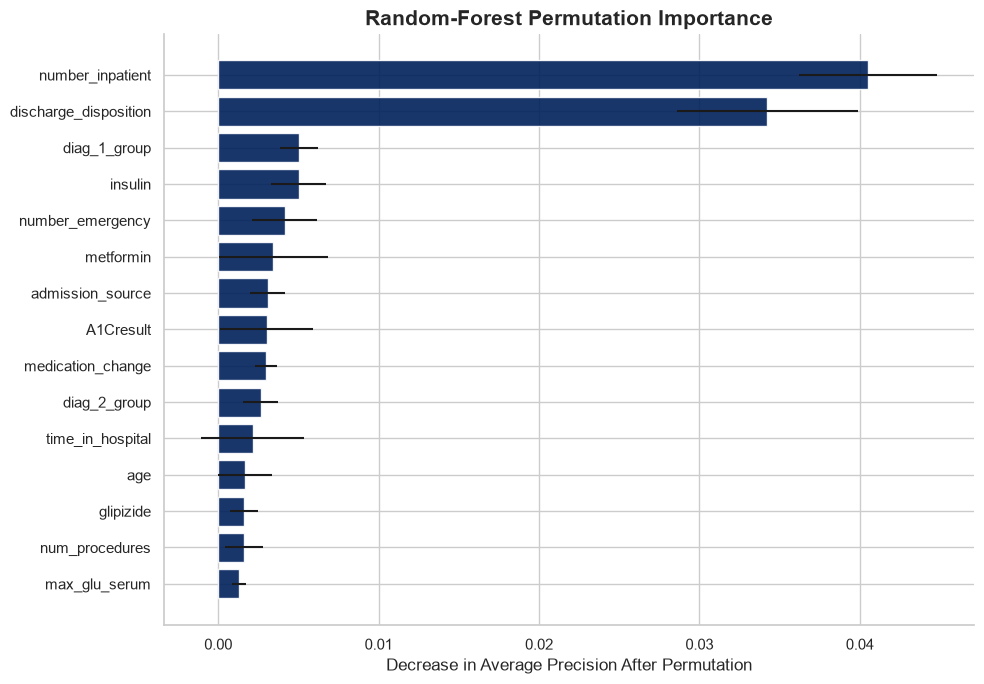

In [73]:
importance_plot_data = (
    permutation_summary
    .head(15)
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    importance_plot_data["feature"],
    importance_plot_data["importance_mean"],
    xerr=importance_plot_data["importance_std"],
    color=VILLANOVA_NAVY,
    alpha=0.9
)

ax.set_title(
    "Random-Forest Permutation Importance",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Decrease in Average Precision After Permutation")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "random_forest_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
def subgroup_metrics(
    model_name,
    probabilities,
    threshold,
    group_column
):
    audit_data = pd.DataFrame({
        "group": (
            X_test[group_column]
            .fillna("Missing")
            .astype(str)
        ),
        "y_true": y_test,
        "probability": probabilities
    })

    audit_data["prediction"] = (
        audit_data["probability"] >= threshold
    ).astype(int)

    records = []

    for group_name, group_data in audit_data.groupby("group"):
        y_group = group_data["y_true"]
        prediction_group = group_data["prediction"]

        tn, fp, fn, tp = confusion_matrix(
            y_group,
            prediction_group,
            labels=[0, 1]
        ).ravel()

        roc_auc = (
            roc_auc_score(
                y_group,
                group_data["probability"]
            )
            if y_group.nunique() == 2
            else np.nan
        )

        records.append({
            "model": model_name,
            "threshold": threshold,
            "group_variable": group_column,
            "group": group_name,
            "encounters": len(group_data),
            "readmissions": int(y_group.sum()),
            "prevalence_pct": y_group.mean() * 100,
            "roc_auc": roc_auc,
            "precision": precision_score(
                y_group,
                prediction_group,
                zero_division=0
            ),
            "recall": recall_score(
                y_group,
                prediction_group,
                zero_division=0
            ),
            "specificity": tn / (tn + fp),
            "false_positive_rate": fp / (tn + fp),
            "false_negative_rate": fn / (fn + tp),
        })

    return pd.DataFrame(records)

In [75]:
audit_models = {
    "Logistic regression": {
        "threshold": 0.15,
        "probabilities": predicted_probabilities[
            "Logistic regression"
        ]
    },
    "Random forest": {
        "threshold": 0.50,
        "probabilities": predicted_probabilities[
            "Random forest"
        ]
    }
}

subgroup_results = []

for model_name, model_details in audit_models.items():
    for group_column in ["race", "gender", "age"]:
        results = subgroup_metrics(
            model_name=model_name,
            probabilities=model_details["probabilities"],
            threshold=model_details["threshold"],
            group_column=group_column
        )

        subgroup_results.append(results)

subgroup_results = pd.concat(
    subgroup_results,
    ignore_index=True
)

subgroup_results.to_csv(
    tables_path / "subgroup_performance.csv",
    index=False
)

subgroup_results.round(3)

,model,threshold,group_variable,group,encounters,readmissions,prevalence_pct,roc_auc,precision,recall,specificity,false_positive_rate,false_negative_rate
0,Logistic regression,0.15,race,AfricanAmerican,3697,399,10.793,0.676,0.216,0.343,0.849,0.151,0.657
1,Logistic regression,0.15,race,Asian,116,10,8.621,0.734,0.118,0.200,0.858,0.142,0.800
2,Logistic regression,0.15,race,Caucasian,14813,1736,11.719,0.664,0.236,0.349,0.851,0.149,0.651
3,Logistic regression,0.15,race,Hispanic,398,36,9.045,0.768,0.262,0.444,0.876,0.124,0.556
4,Logistic regression,0.15,race,Missing,447,32,7.159,0.643,0.154,0.188,0.920,0.080,0.812
5,Logistic regression,0.15,race,Other,302,31,10.265,0.685,0.323,0.323,0.923,0.077,0.677
6,Logistic regression,0.15,gender,Female,10726,1228,11.449,0.677,0.240,0.357,0.854,0.146,0.643
7,Logistic regression,0.15,gender,Male,9047,1016,11.230,0.659,0.223,0.333,0.853,0.147,0.667
8,Logistic regression,0.15,age,[0-10),26,2,7.692,0.667,0.000,0.000,1.000,0.000,1.000
9,Logistic regression,0.15,age,[10-20),137,8,5.839,0.763,0.000,0.000,0.992,0.008,1.000


In [76]:
for group_variable in ["race", "gender", "age"]:
    print(f"\nPerformance by {group_variable}:")

    display(
        subgroup_results[
            subgroup_results["group_variable"]
            == group_variable
        ][
            [
                "model",
                "group",
                "encounters",
                "readmissions",
                "prevalence_pct",
                "roc_auc",
                "precision",
                "recall",
                "false_positive_rate",
                "false_negative_rate"
            ]
        ].round(3)
    )


Performance by race:


,model,group,encounters,readmissions,prevalence_pct,roc_auc,precision,recall,false_positive_rate,false_negative_rate
0,Logistic regression,AfricanAmerican,3697,399,10.793,0.676,0.216,0.343,0.151,0.657
1,Logistic regression,Asian,116,10,8.621,0.734,0.118,0.200,0.142,0.800
2,Logistic regression,Caucasian,14813,1736,11.719,0.664,0.236,0.349,0.149,0.651
3,Logistic regression,Hispanic,398,36,9.045,0.768,0.262,0.444,0.124,0.556
4,Logistic regression,Missing,447,32,7.159,0.643,0.154,0.188,0.080,0.812
5,Logistic regression,Other,302,31,10.265,0.685,0.323,0.323,0.077,0.677
18,Random forest,AfricanAmerican,3697,399,10.793,0.663,0.182,0.524,0.285,0.476
19,Random forest,Asian,116,10,8.621,0.697,0.179,0.500,0.217,0.500
20,Random forest,Caucasian,14813,1736,11.719,0.674,0.194,0.559,0.307,0.441
21,Random forest,Hispanic,398,36,9.045,0.782,0.202,0.556,0.218,0.444



Performance by gender:


,model,group,encounters,readmissions,prevalence_pct,roc_auc,precision,recall,false_positive_rate,false_negative_rate
6,Logistic regression,Female,10726,1228,11.449,0.677,0.240,0.357,0.146,0.643
7,Logistic regression,Male,9047,1016,11.230,0.659,0.223,0.333,0.147,0.667
24,Random forest,Female,10726,1228,11.449,0.687,0.195,0.586,0.313,0.414
25,Random forest,Male,9047,1016,11.230,0.661,0.187,0.506,0.278,0.494



Performance by age:


,model,group,encounters,readmissions,prevalence_pct,roc_auc,precision,recall,false_positive_rate,false_negative_rate
8,Logistic regression,[0-10),26,2,7.692,0.667,0.000,0.000,0.000,1.000
9,Logistic regression,[10-20),137,8,5.839,0.763,0.000,0.000,0.008,1.000
10,Logistic regression,[20-30),369,60,16.260,0.845,0.438,0.650,0.162,0.350
11,Logistic regression,[30-40),757,87,11.493,0.699,0.255,0.299,0.113,0.701
12,Logistic regression,[40-50),1909,183,9.586,0.683,0.237,0.268,0.092,0.732
13,Logistic regression,[50-60),3467,377,10.874,0.724,0.337,0.332,0.080,0.668
14,Logistic regression,[60-70),4356,504,11.570,0.661,0.247,0.343,0.137,0.657
15,Logistic regression,[70-80),4921,556,11.299,0.661,0.207,0.376,0.184,0.624
16,Logistic regression,[80-90),3284,399,12.150,0.605,0.183,0.351,0.216,0.649
17,Logistic regression,[90-100),547,68,12.431,0.498,0.156,0.221,0.169,0.779


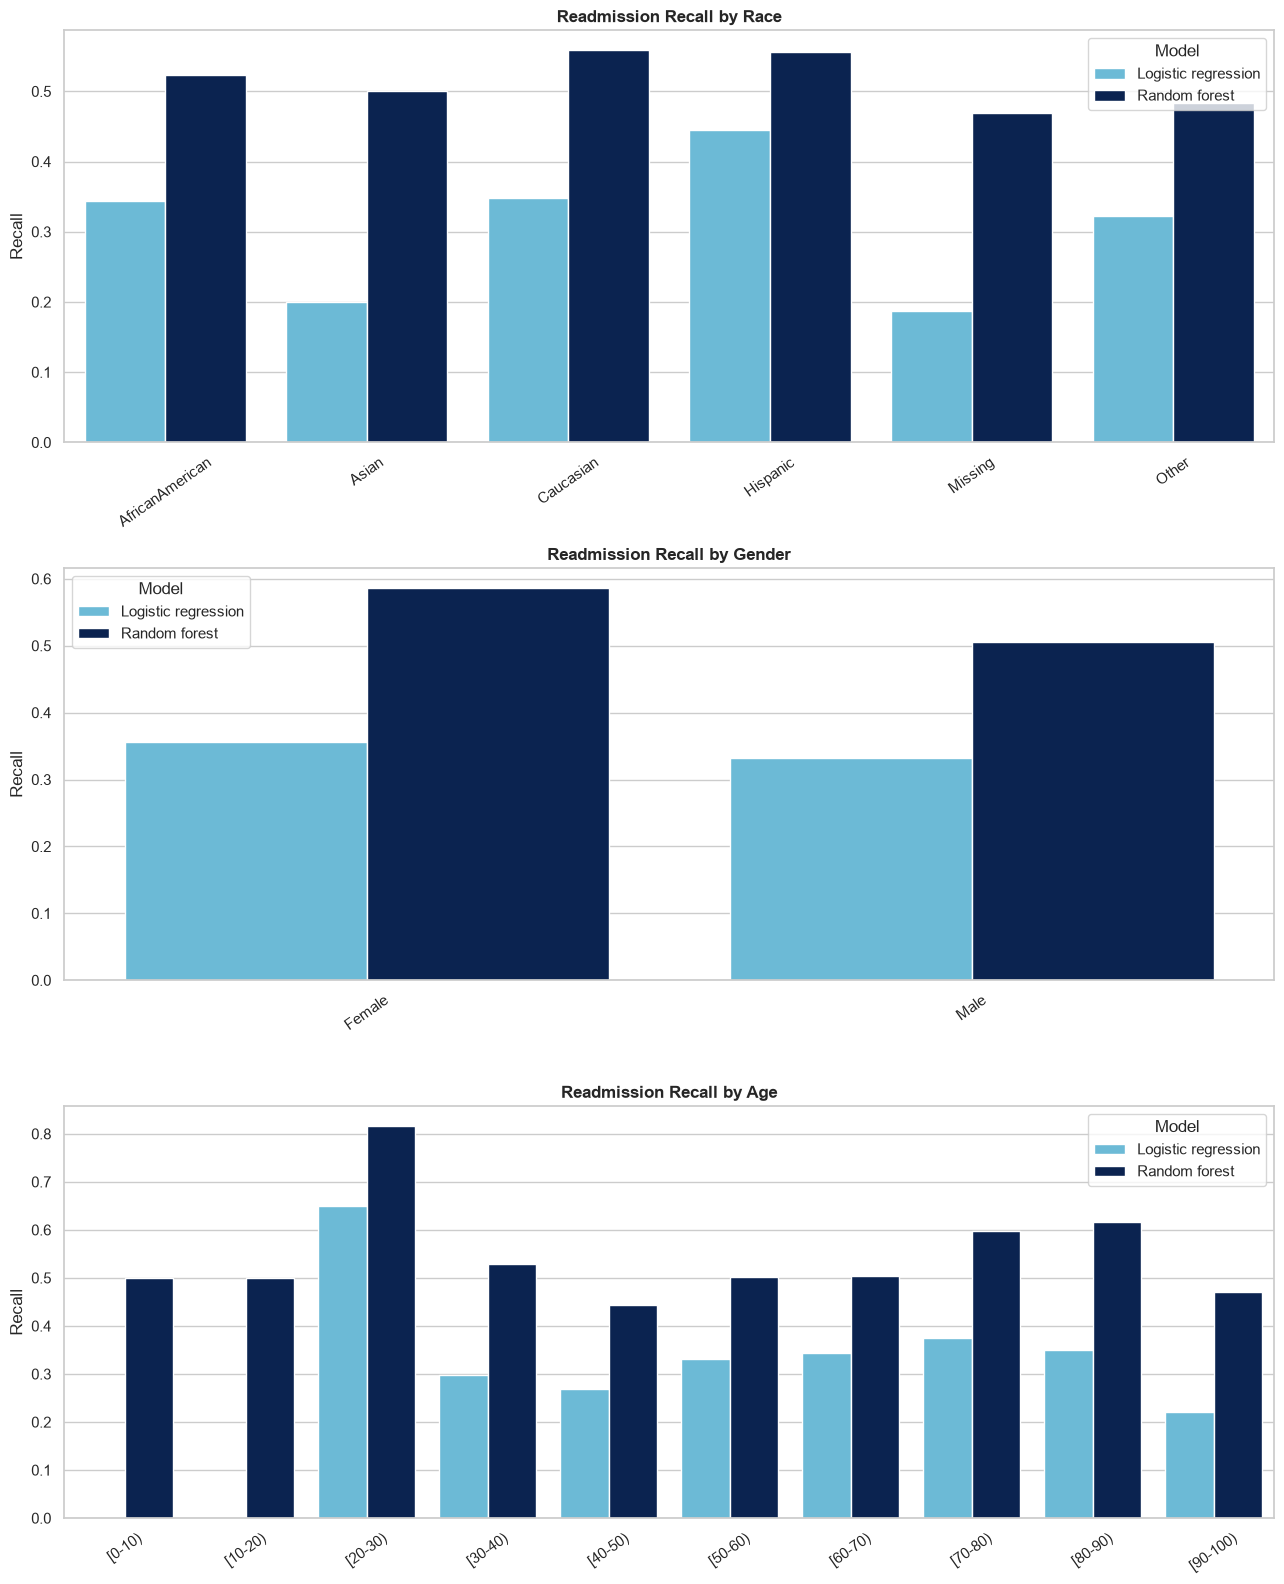

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(13, 16))

for ax, group_variable in zip(
    axes,
    ["race", "gender", "age"]
):
    plot_data = subgroup_results[
        subgroup_results["group_variable"]
        == group_variable
    ].copy()

    sns.barplot(
        data=plot_data,
        x="group",
        y="recall",
        hue="model",
        palette=[LIGHT_BLUE, VILLANOVA_NAVY],
        ax=ax
    )

    ax.set_title(
        f"Readmission Recall by {group_variable.title()}",
        fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("Recall")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Model")

plt.tight_layout()

plt.savefig(
    figures_path / "subgroup_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model interpretation and subgroup audit

### Important predictors

Previous inpatient utilization was the strongest consistent predictor across the two modeling approaches. `number_inpatient` had the largest random-forest permutation importance and a positive logistic-regression coefficient. This agrees with the exploratory finding that encounters involving patients with three or more inpatient visits during the preceding year had substantially higher readmission rates.

Discharge disposition was also highly influential. Because disposition is closely related to the transition following hospitalization, its predictive contribution requires cautious interpretation. Although it is available at discharge, it may capture healthcare-system processes and follow-up arrangements rather than underlying patient risk.

Some individual medication categories had large logistic coefficients but may contain few observations. Large coefficients for rare categories may be unstable and should not be interpreted as evidence that those medications cause readmission.

Numeric variables were standardized before logistic-regression modeling. Therefore, numeric odds ratios represent a one-standard-deviation increase rather than a one-unit increase. Categorical coefficients represent comparisons with an omitted reference category.

### Race audit

For the two largest recorded racial groups, performance differences were relatively modest:

- Logistic-regression recall was 34.3% for African American patients and 34.9% for Caucasian patients.
- Random-forest recall was 52.4% for African American patients and 55.9% for Caucasian patients.
- Random-forest false-positive rates were 28.5% for African American patients and 30.7% for Caucasian patients.

Results for Asian, Hispanic, Other, and missing-race categories are based on substantially fewer encounters and readmissions. Their estimates are therefore less stable and should not be used to claim superior or inferior model performance.

### Gender audit

Performance also differed by recorded gender:

- Logistic-regression recall was 35.7% for female patients and 33.3% for male patients.
- Random-forest recall was 58.6% for female patients and 50.6% for male patients.
- Random-forest false-positive rates were 31.3% for female patients and 27.8% for male patients.

The dataset records gender using only broad binary categories after removal of three `Unknown/Invalid` records. It does not support analysis of gender identity beyond those recorded categories.

### Age audit

Age showed the greatest variation in model errors. Among the larger age groups, the random forest generally produced higher recall but increasingly high false-positive rates among older patients. The false-positive rate reached 44.6% for patients ages 80–89.

Discrimination was weak among patients ages 90–99, with ROC-AUC values near 0.50. Results for patients under age 20 are especially unstable because those groups contain very few encounters and readmissions.

### Responsible interpretation

Model errors were not distributed identically across demographic groups. However, differences in subgroup size, outcome prevalence, clinical characteristics, and missing data affect these comparisons. The audit does not establish that the models are fair or unfair, and it does not identify the causes of observed performance differences.

A real clinical application would require larger contemporary validation samples, uncertainty estimates, stakeholder involvement, investigation of structural inequities, and explicit fairness criteria. Demographic variables and predictive importance should not be interpreted as evidence of biological causation.